# Edge Detection

Author(s): Raj Magesh Gauthaman (rgautha1@jh.edu)

Reference: [Konishi et al. (2003)](https://doi.org/10.1109/TPAMI.2003.1159946)

---

This notebook implements an edge detection algorithm.

## Utilities

In [1]:
from __future__ import annotations
from collections.abc import Collection
import itertools

import numpy as np
import numpy.typing as npt
import torch
import torch.nn as nn
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.stats import gaussian_kde
from PIL import Image


def plot_image(image: npt.NDArray, **kwargs) -> mpl.figure.Figure:
    """Plot an image."""
    fig, ax = plt.subplots()
    ax.axis("off")
    ax.imshow(image, cmap="gray", **kwargs)
    fig.show()


def load_data(id: int = 0) -> tuple[np.ndarray, np.ndarray]:
    """id can be from 0 to 6 (inclusive)."""
    edge_map = np.array(Image.open(f"data/edge_detection/edge_maps/{id}.bmp").convert("1"))
    image = np.array(Image.open(f"data/edge_detection/images/{id}.jpg").convert("L")).astype(float)
    image /= 255
    return image, edge_map


def compute_gradient(image: npt.NDArray[float]) -> npt.NDArray[float]:
    dx, dy = np.gradient(image)
    return np.sqrt(dx ** 2 + dy ** 2)

## Algorithm

### Loading the data

Let's load an image and its hand-annotated edge map.

/var/folders/kq/zd50rskj7d1dqxnrr7s5q3bc0000gq/T/ipykernel_50475/1888753972.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


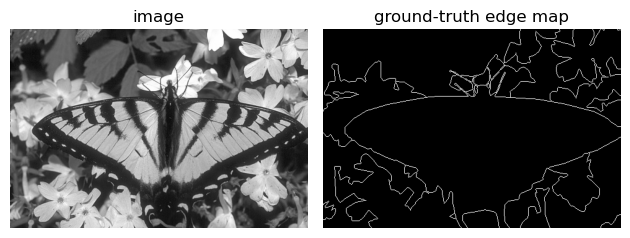

In [2]:
image, ground_truth = load_data(2)

fig, axes = plt.subplots(nrows=1, ncols=2)
axes[0].imshow(image, cmap="gray")
axes[0].set_title("image")
axes[1].imshow(ground_truth, cmap="gray")
axes[1].set_title("ground-truth edge map")

for ax in axes.flat:
    ax.axis("off")

fig.tight_layout()
fig.show()

### Effect of smoothing

We compute the gradient of the image (i) directly and (ii) after smoothing with a Gaussian filter, and visualize the magnitude of the gradient.

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/var/folders/kq/zd50rskj7d1dqxnrr7s5q3bc0000gq/T/ipykernel_50475/3699471424.py:5: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title("$|\\nabla (G \star I)|$")
/var/folders/kq/zd50rskj7d1dqxnrr7s5q3bc0000gq/T/ipykernel_50475/3699471424.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


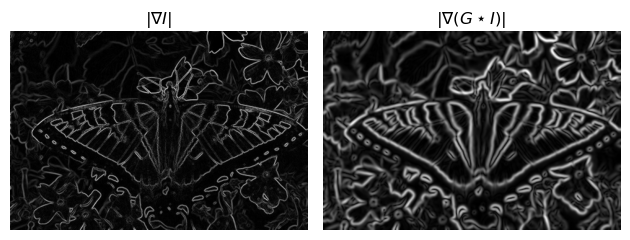

In [3]:
fig, axes = plt.subplots(nrows=1, ncols=2)
axes[0].imshow(compute_gradient(image), cmap="gray")
axes[0].set_title("$|\\nabla I|$")
axes[1].imshow(compute_gradient(gaussian_filter(image, sigma=2)), cmap="gray")
axes[1].set_title("$|\\nabla (G \star I)|$")

for ax in axes.flat:
    ax.axis("off")
    
fig.tight_layout()
fig.show()

### Computing likelihoods

Here, we compute the distribution of the gradient magnitudes for edge and non-edge pixels.

/var/folders/kq/zd50rskj7d1dqxnrr7s5q3bc0000gq/T/ipykernel_50475/3339153240.py:44: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


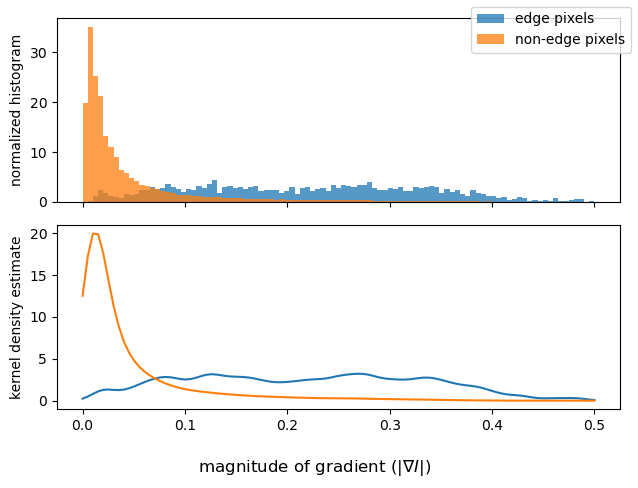

In [4]:
def find_gradient_on_edge(gradient: npt.NDArray[float], edge_map: npt.NDArray[bool]) -> npt.NDArray[float]:
    indices = np.nonzero(edge_map.flatten())

    # allow for inaccurate boundary labelling by finding edge pixel in a 3x3 neighborhood
    [offx, offy] = np.meshgrid(np.arange(-1, 2), np.arange(-1, 2))
    offx = offx.flatten()
    offy = offy.flatten()

    gradient_copy = np.copy(gradient)
    for i in range(9):
        im = np.roll(gradient, offx[i], axis=1) # x axis
        im = np.roll(im, offy[i], axis=0) # y axis    
        gradient_copy = np.maximum(gradient_copy, im)

    return gradient_copy.flatten()[indices]


def find_gradient_off_edge(gradient: npt.NDArray[float], edge_map: npt.NDArray[bool]) -> npt.NDArray[float]:
    indices = np.nonzero(~edge_map)
    return gradient[indices] 


gradient = compute_gradient(image)

on = find_gradient_on_edge(gradient, ground_truth)
kde_on = gaussian_kde(on, bw_method=0.01 / on.std(ddof=1))
off = find_gradient_off_edge(gradient, ground_truth)
kde_off = gaussian_kde(off, bw_method=0.01 / off.std(ddof=1))

bins = np.linspace(0, 0.5, 100)

fig, axes = plt.subplots(nrows=2, ncols=1, sharex=True)
axes[0].hist(on, bins=bins, label="edge pixels", alpha=0.75, density=True)
axes[0].hist(off, bins=bins, label=r"non-edge pixels", alpha=0.75, density=True)
axes[0].set_ylabel("normalized histogram")

axes[1].plot(bins, kde_on(bins))
axes[1].plot(bins, kde_off(bins))
axes[1].set_ylabel("kernel density estimate")

fig.legend()
fig.supxlabel("magnitude of gradient ($|\\nabla I |$)")
fig.tight_layout()
fig.show()

### Classification

Now, we can classify pixels as edge pixels or non-edge pixels. Note: this cell will take a long time (~10 min) to run.

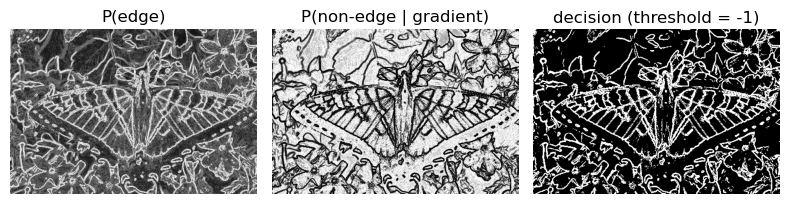

In [5]:
p_on = kde_on(gradient.flatten()).reshape(gradient.shape)
p_off = kde_off(gradient.flatten()).reshape(gradient.shape)

threshold = -1
decision = np.log(p_on / p_off) > threshold

fig, axes = plt.subplots(ncols=3, figsize=(8, 4))
axes[0].imshow(p_on, cmap="gray")
axes[0].set_title("P(edge)")
axes[1].imshow(p_off, cmap="gray")
axes[1].set_title("P(non-edge | gradient)")
axes[2].imshow(decision, cmap="gray")
axes[2].set_title(f"decision (threshold = {threshold})")

for ax in axes.flat:
    ax.axis("off")
fig.tight_layout()

### ROC curve

Now that we can classify pixels as either edge pixels or non-edge pixels, we can compute an ROC curve by varying the decision threshold.

/var/folders/kq/zd50rskj7d1dqxnrr7s5q3bc0000gq/T/ipykernel_50475/2629957465.py:35: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


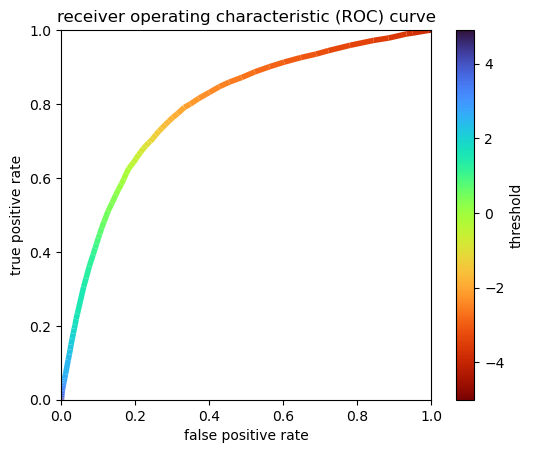

In [6]:
def compute_roc(criterion: npt.NDArray[float], ground_truth: npt.NDArray[bool], thresholds: Collection[float]) -> tuple[npt.NDArray[float], npt.NDArray[float]]:
    prediction = np.stack([criterion >= threshold for threshold in thresholds])

    true_positive = prediction & ground_truth
    true_negative = ~prediction & ~ground_truth

    false_positive = prediction & ~ground_truth
    false_negative = ~prediction & ground_truth

    true_positive_rate = true_positive.sum(axis=(-2, -1)) / ground_truth.sum()
    false_positive_rate = false_positive.sum(axis=(-2, -1)) / (~ground_truth).sum()
    return true_positive_rate, false_positive_rate


criterion = np.log(p_on / p_off)
thresholds = np.arange(-5, 5, step=0.1)
tpr, fpr = compute_roc(criterion, ground_truth=ground_truth, thresholds=thresholds)

fig, ax = plt.subplots()

points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = plt.Normalize(thresholds.min(), thresholds.max())
lc = mpl.collections.LineCollection(segments=segments, cmap="turbo_r", norm=norm, linewidth=4)
lc.set_array(thresholds)
line = ax.add_collection(lc)
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.axis("square")
ax.set_xlim(left=0, right=1)
ax.set_ylim(bottom=0, top=1)
ax.set_title("receiver operating characteristic (ROC) curve")
cb = fig.colorbar(line, ax=ax, label="threshold")
fig.show()

## Questions

### Q1 (6 points)

Load another image and apply this edge detection algorithm. Find a good threshold and display your result.

### Q2 (8 points)

Repeat Q1 using the image gradient after smoothing the image (i.e. $\nabla G \star I$ instead of $\nabla I$). Show your results for a couple of different variances ($\sigma^2$) of the Gaussian filter.

In [7]:
savefolder = "submissions/"

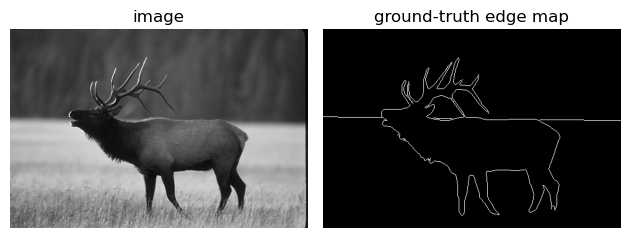

In [8]:
image, ground_truth = load_data(3)

fig, axes = plt.subplots(nrows=1, ncols=2)
axes[0].imshow(image, cmap="gray")
axes[0].set_title("image")
axes[1].imshow(ground_truth, cmap="gray")
axes[1].set_title("ground-truth edge map")

for ax in axes.flat:
    ax.axis("off")

fig.tight_layout()
fig.savefig(savefolder+"edge_detection_image_3.png", dpi=300)

In [9]:
sigmas = [1, 2, 3, 4]
gradient_without_smoothing = compute_gradient(image)
gradients = np.array([gradient_without_smoothing] + [compute_gradient(gaussian_filter(image, sigma=sigma)) for sigma in sigmas])
ons = np.array([find_gradient_on_edge(gradient, ground_truth) for gradient in gradients])
offs = np.array([find_gradient_off_edge(gradient, ground_truth) for gradient in gradients])
kde_ons = np.array([gaussian_kde(on, bw_method=0.01 / on.std(ddof=1)) for on in ons])
kde_offs = np.array([gaussian_kde(off, bw_method=0.01 / off.std(ddof=1)) for off in offs])
p_ons = np.array([kde_on(gradient.flatten()).reshape(gradient.shape) for kde_on, gradient in zip(kde_ons, gradients)])
p_offs = np.array([kde_off(gradient.flatten()).reshape(gradient.shape) for kde_off, gradient in zip(kde_offs, gradients)])
criteria = np.log(p_ons / p_offs)
thresholds = np.arange(-5, 5, step=0.1)
roc_curves = np.array([compute_roc(criterion, ground_truth, thresholds=thresholds) for criterion in criteria])
optimal_thresholds = [thresholds[np.argmax(roc_curves[i, 0]-roc_curves[i, 1])] for i in range(len(sigmas)+1)]

In [10]:
optimal_rates = np.array([roc_curves[i,:,np.where(thresholds==optimal_thresholds[i])[0][0]] for i in range(len(sigmas)+1)])

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/var/folders/kq/zd50rskj7d1dqxnrr7s5q3bc0000gq/T/ipykernel_50475/4024337168.py:6: SyntaxWarning: invalid escape sequence '\s'
  axes[i,1].set_title(f"$| \\nabla (G_{{ \\sigma = {sigma}}} \star I)|$");


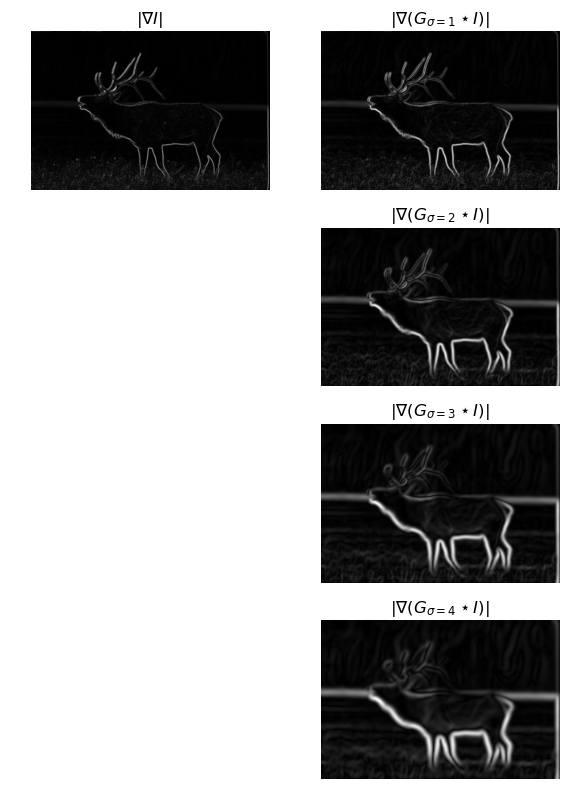

In [11]:
fig, axes = plt.subplots(figsize=(2*3, (len(sigmas))*2), ncols = 2, nrows=len(sigmas))
axes[0,0].imshow(gradients[0], cmap="gray")
axes[0,0].set_title(r"$| \nabla I|$")
for i, sigma in enumerate(sigmas):
    axes[i,1].imshow(gradients[i+1], cmap="gray")
    axes[i,1].set_title(f"$| \\nabla (G_{{ \\sigma = {sigma}}} \star I)|$");

for ax in axes.flat:
    ax.axis("off")
    
fig.tight_layout()
fig.savefig(savefolder+"edge_detection_gradients_image_3.png", dpi=300)

<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
/var/folders/kq/zd50rskj7d1dqxnrr7s5q3bc0000gq/T/ipykernel_50475/236964226.py:27: SyntaxWarning: invalid escape sequence '\s'
  axes[2*i+1, 1].set_xlabel(f"magnitude of gradient ($| \\nabla (G_{{ \\sigma = {sigma}}} \star I)|$)", fontsize = 10)


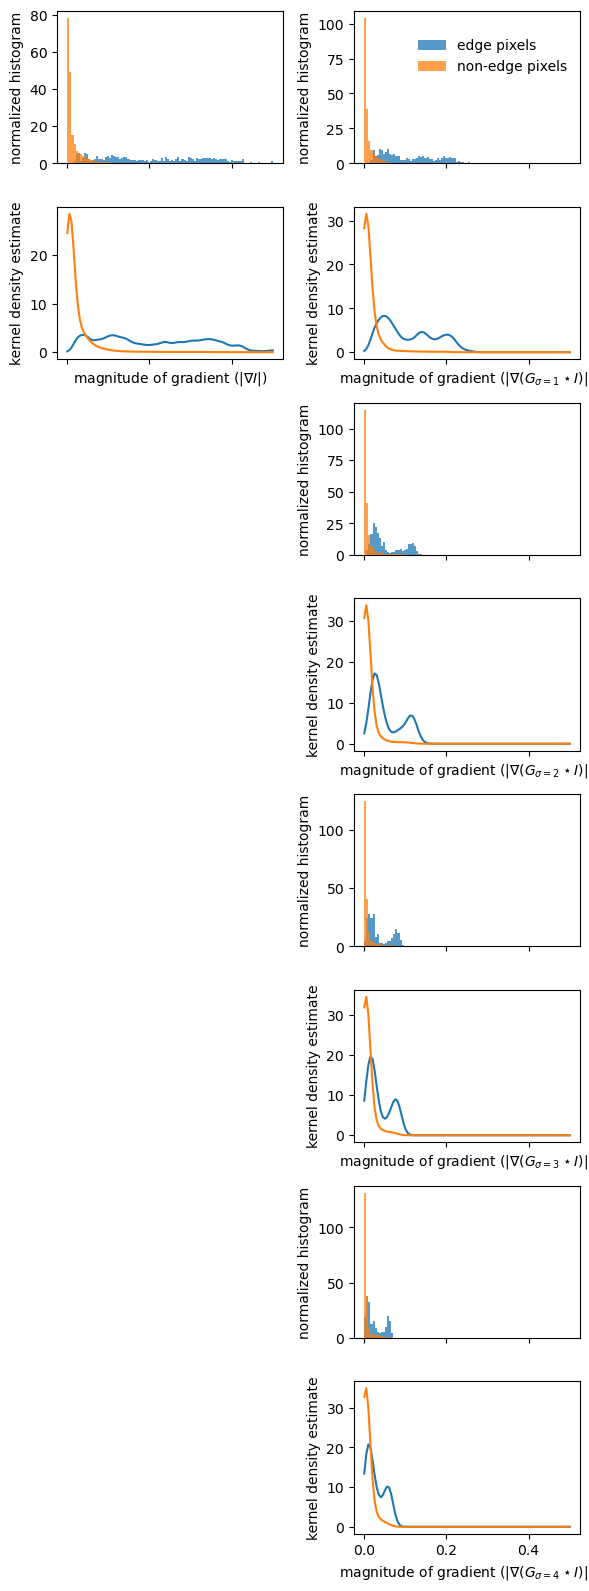

In [12]:
bins = np.linspace(0, 0.5, 100)

fig, axes = plt.subplots(figsize = (6, 4*len(sigmas)), nrows=2*len(sigmas), ncols=2, sharex=True)
axes[0, 0].hist(ons[0], bins=bins, label="edge pixels", alpha=0.75, density=True)
axes[0, 0].hist(offs[0], bins=bins, label=r"non-edge pixels", alpha=0.75, density=True)
axes[0, 0].set_ylabel("normalized histogram")

axes[1, 0].plot(bins, kde_ons[0](bins))
axes[1, 0].plot(bins, kde_offs[0](bins))
axes[1, 0].set_ylabel("kernel density estimate")

axes[1, 0].set_xlabel("magnitude of gradient ($|\\nabla I |$)", fontsize = 10)

for i in range(2, 2*len(sigmas)):
    fig.delaxes(axes[i, 0])

for i, sigma in enumerate(sigmas):

    axes[2*i, 1].hist(ons[i+1], bins=bins, label="edge pixels", alpha=0.75, density=True)
    axes[2*i, 1].hist(offs[i+1], bins=bins, label=r"non-edge pixels", alpha=0.75, density=True)
    axes[2*i, 1].set_ylabel("normalized histogram")

    axes[2*i+1, 1].plot(bins, kde_ons[i+1](bins))
    axes[2*i+1, 1].plot(bins, kde_offs[i+1](bins))
    axes[2*i+1, 1].set_ylabel("kernel density estimate")

    axes[2*i+1, 1].set_xlabel(f"magnitude of gradient ($| \\nabla (G_{{ \\sigma = {sigma}}} \star I)|$)", fontsize = 10)
axes[0, 1].legend(frameon=False, loc='upper right', bbox_to_anchor=(1, 0.9))

fig.tight_layout()
fig.savefig(savefolder+"edge_detection_histograms_image_3.png", dpi=300)

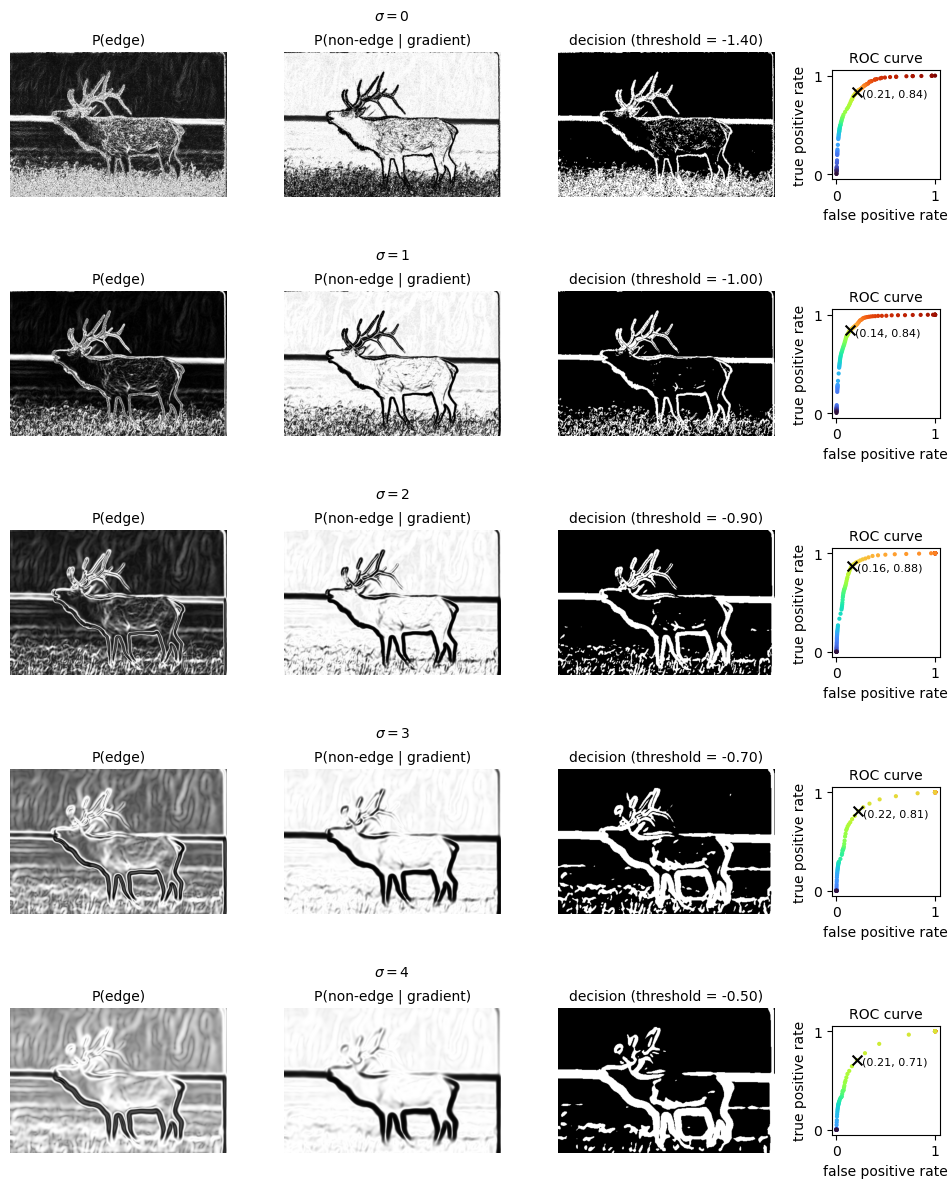

In [13]:
fig, axes = plt.subplots(ncols=4, nrows = (len(sigmas)+1), figsize=(12, 3*(len(sigmas)+1)), gridspec_kw={'width_ratios':[1,1,1,0.5], 'wspace':0.3})
for i in range(len(sigmas)+1):

    threshold = optimal_thresholds[i]
    decision = np.log(p_ons[i] / p_offs[i]) > threshold

    axes[i, 0].imshow(p_ons[i], cmap="gray")
    axes[i, 0].set_title("P(edge)", fontsize=10)
    axes[i, 1].imshow(p_offs[i], cmap="gray")
    axes[i, 1].set_title("P(non-edge | gradient)", fontsize=10)
    axes[i, 2].imshow(decision, cmap="gray")
    axes[i, 2].set_title(f"decision (threshold = {threshold:.2f})", fontsize=10)
    axes[i, 3].scatter(roc_curves[i, 1], roc_curves[i, 0], c=thresholds, cmap="turbo_r", s=4)
    axes[i, 3].scatter(optimal_rates[i,1], optimal_rates[i,0], marker = "x", color="black", s=50)
    axes[i, 3].text(optimal_rates[i,1]+0.05, optimal_rates[i,0]-0.05, f"({optimal_rates[i,1]:.2f}, {optimal_rates[i,0]:.2f})", fontsize=8)
    axes[i, 3].set_xlabel("false positive rate")
    axes[i, 3].set_ylabel("true positive rate")
    axes[i, 3].axis("square")
    axes[i, 3].set_xticks([0, 1])
    axes[i, 3].set_yticks([0, 1])
    axes[i, 3].set_title("ROC curve", fontsize=10)
    axes[i, 1].text(0.5, 1.25, f"$\\sigma = {0 if i == 0 else sigmas[i-1]}$", fontsize=10, ha='center', va='center', color='k', transform=axes[i, 1].transAxes)

for ax in axes[:,:3].flat:
    ax.axis("off")
fig.savefig(savefolder+"edge_detection_final_decisions_image_3.png", dpi=300)